In [29]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import os

In [30]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.6.0


In [31]:
# Check and display the number of GPUs available for model training

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [32]:
# Define constants for image preprocessing, batching, and training parameters.
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 25

In [33]:
import shutil
import random

# Paths
original_data_dir = 'Apple-leaf-disease-dataset'
new_data_dir = 'Apple-leaf-disease-dataset-oversampled'

# Class directories and their respective counts
class_counts = {
    'Apple___alternaria_leaf_spot': 278,
    'Apple___black_rot': 621,
    'Apple___brown_spot': 215,
    'Apple___gray_spot': 395,
    'Apple___healthy': 2570,
    'Apple___rust': 1241,
    'Apple___scab': 1222
}


# Maximum class size (majority class size)
max_class_size = class_counts['Apple___healthy']

# Create the new directory structure for oversampled images
for class_name in class_counts:
    class_path = os.path.join(original_data_dir, class_name)
    new_class_path = os.path.join(new_data_dir, class_name)
    
    # Create the new class folder if it doesn't exist
    if not os.path.exists(new_class_path):
        os.makedirs(new_class_path)

    # Get list of all image files in the original class folder
    image_files = os.listdir(class_path)
    
    # Calculate how many times to repeat images for minority classes
    if len(image_files) < max_class_size:
        # Oversample by duplicating images until the class size reaches the majority class size
        num_duplicates = max_class_size - len(image_files)
        
        # Copy the original images to the new directory
        for image in image_files:
            src_image_path = os.path.join(class_path, image)
            dst_image_path = os.path.join(new_class_path, image)
            shutil.copy(src_image_path, dst_image_path)
        
        # Oversample the minority class by duplicating the images
        while num_duplicates > 0:
            for image in image_files:
                if num_duplicates <= 0:
                    break
                src_image_path = os.path.join(class_path, image)
                dst_image_path = os.path.join(new_class_path, f"oversampled_{num_duplicates}_{image}")
                shutil.copy(src_image_path, dst_image_path)
                num_duplicates -= 1
    else:
        # If the class is already the majority class, just copy the images to the new folder
        for image in image_files:
            src_image_path = os.path.join(class_path, image)
            dst_image_path = os.path.join(new_class_path, image)
            shutil.copy(src_image_path, dst_image_path)

print("Oversampling complete. New dataset created in:", new_data_dir)



Oversampling complete. New dataset created in: Apple-leaf-disease-dataset-oversampled


In [34]:
# Loading the dataset
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "Apple-leaf-disease-dataset-oversampled",
    shuffle=True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE


)

Found 17990 files belonging to 7 classes.


In [35]:
# Retrieve and display the class names from the dataset for categorization.
class_names = dataset.class_names
class_names

['Apple___alternaria_leaf_spot',
 'Apple___black_rot',
 'Apple___brown_spot',
 'Apple___gray_spot',
 'Apple___healthy',
 'Apple___rust',
 'Apple___scab']

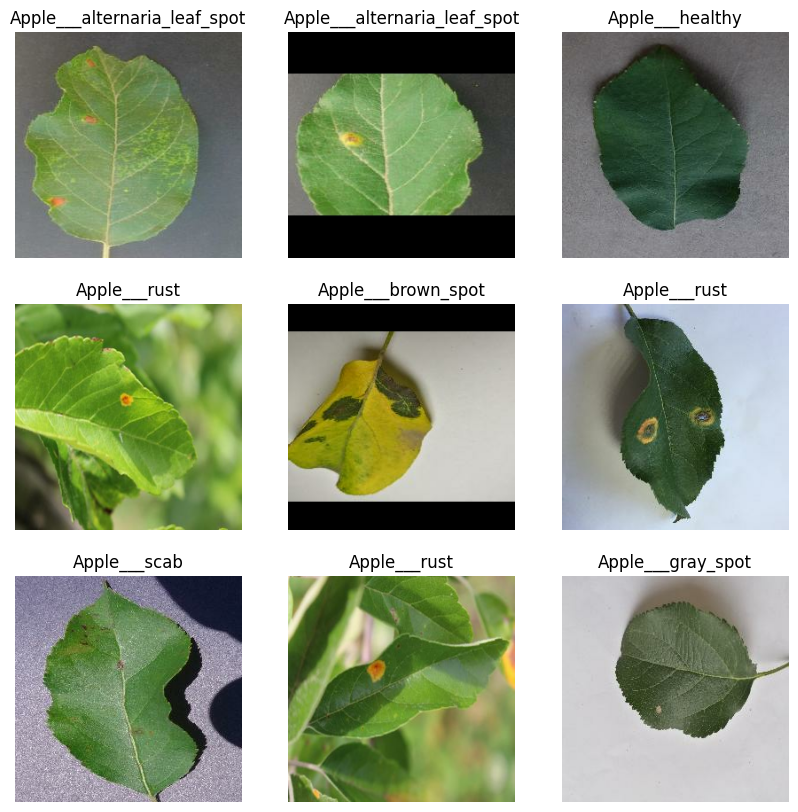

In [36]:
# Visualize a sample of the images from the dataset along with their labels.

plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis("off")
        plt.title(class_names[label_batch[i]])

In [37]:
# Display the total number of batches in the dataset.
len(dataset)

563

In [38]:
# Function to split the dataset into training, validation, and test sets.

def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=1000):
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12) # Shuffle the dataset for randomness in training
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [39]:
# Split the dataset into training, validation, and test partitions.

train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [40]:
# Display the number of batches in the training dataset.
len(train_ds)


450

In [41]:
# Display the number of batches in the validation dataset.
len(val_ds)

56

In [42]:
# Display the number of batches in the testing dataset.
len(test_ds)

57

In [43]:
# Apply caching, shuffling, and prefetching to the datasets for better performance during training.

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [44]:
# Define the preprocessing pipeline that resizes and rescales images to a uniform format.

resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0/255)
])


In [45]:
# Define the data augmentation pipeline to apply random transformations to the images.

data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2),
    layers.experimental.preprocessing.RandomZoom(0.2),
    layers.experimental.preprocessing.RandomContrast(0.1),
    
])

In [46]:
# Build the model architecture by stacking convolutional, pooling, and dense layers.

input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)
model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size = (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size = (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
    
    
])
model.build(input_shape=input_shape)

In [47]:
# Summarize the model architecture to display the number of parameters and layer configurations.

model.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential_3 (Sequential)    (32, 256, 256, 3)         0         
_________________________________________________________________
sequential_4 (Sequential)    (32, 256, 256, 3)         0         
_________________________________________________________________
conv2d_6 (Conv2D)            (32, 254, 254, 32)        896       
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (32, 127, 127, 32)        0         
_________________________________________________________________
conv2d_7 (Conv2D)            (32, 125, 125, 64)        18496     
_________________________________________________________________
max_pooling2d_7 (MaxPooling2 (32, 62, 62, 64)          0         
_________________________________________________________________
conv2d_8 (Conv2D)            (32, 60, 60, 64)         

In [48]:
# Compile the model with the Adam optimizer and sparse categorical crossentropy loss function.

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']

)

In [49]:
# Train the model on the training dataset and validate on the validation dataset.

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=val_ds
)

Epoch 1/25
450/450 [==============================] - 197s 271ms/step - loss: 1.2138 - accuracy: 0.5093 - val_loss: 0.7596 - val_accuracy: 0.7210
Epoch 2/25
450/450 [==============================] - 73s 162ms/step - loss: 0.5510 - accuracy: 0.7980 - val_loss: 0.4118 - val_accuracy: 0.8320
Epoch 3/25
450/450 [==============================] - 60s 133ms/step - loss: 0.3316 - accuracy: 0.8848 - val_loss: 0.2207 - val_accuracy: 0.9275
Epoch 4/25
450/450 [==============================] - 67s 149ms/step - loss: 0.2630 - accuracy: 0.9076 - val_loss: 0.2464 - val_accuracy: 0.9124
Epoch 5/25
450/450 [==============================] - 65s 145ms/step - loss: 0.2104 - accuracy: 0.9269 - val_loss: 0.1298 - val_accuracy: 0.9520
Epoch 6/25
450/450 [==============================] - 61s 134ms/step - loss: 0.1737 - accuracy: 0.9391 - val_loss: 0.1492 - val_accuracy: 0.9448
Epoch 7/25
450/450 [==============================] - 63s 141ms/step - loss: 0.1585 - accuracy: 0.9440 - val_loss: 0.1324 - val_a

In [50]:
# Evaluate the model performance on the test dataset.

scores = model.evaluate(test_ds)

57/57 [==============================] - 61s 48ms/step - loss: 0.0539 - accuracy: 0.9819


In [51]:
# Calculate precision, recall, and F1 score for the model's predictions on the test set.

from sklearn.metrics import precision_score, recall_score, f1_score

# Initialize lists to store true and predicted labels
y_true = []
y_pred = []

# Iterate over the test dataset to collect true and predicted labels
for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = labels.numpy()
    
    y_pred.extend(predicted_classes)
    y_true.extend(true_classes)

# Convert lists to numpy arrays for metric calculation
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute the metrics
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Precision: 0.9822068746930263
Recall: 0.9819078947368421
F1 Score: 0.9818370635930331


In [52]:
# Store the training and validation accuracy and loss for visualization.

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Loss')

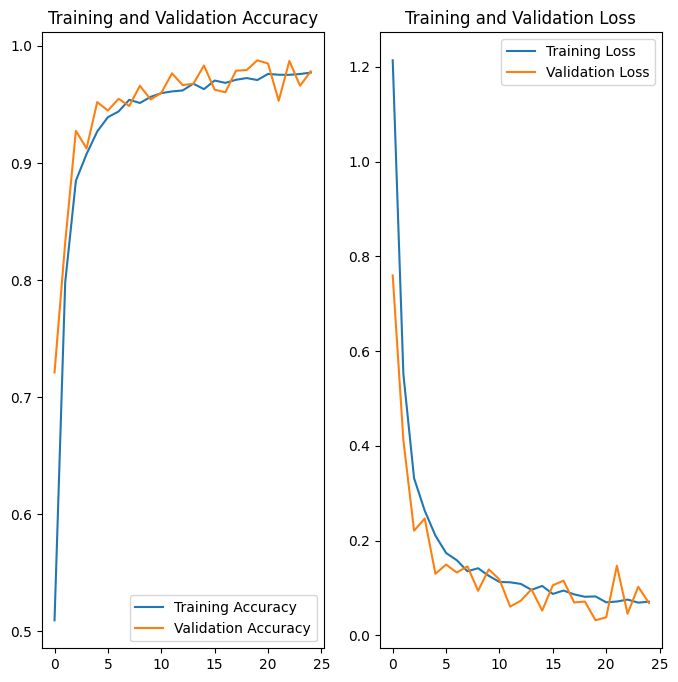

In [53]:
# Visualize the training and validation accuracy and loss over the epochs.

plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label="Training Accuracy")
plt.plot(range(EPOCHS), val_acc, label="Validation Accuracy")
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label="Training Loss")
plt.plot(range(EPOCHS), val_loss, label="Validation Loss")
plt.legend(loc='upper right')
plt.title("Training and Validation Loss")

first image to predict
actual label:  Apple___scab
predicted label:  Apple___scab


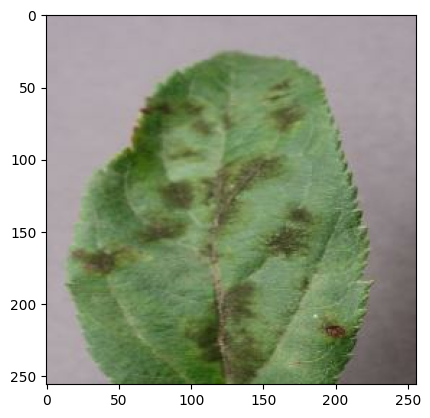

In [54]:
# Display a sample image along with its predicted label for visual inspection.

for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label: ", class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label: ",class_names[np.argmax(batch_prediction[0])])

In [55]:
# Save the trained model with versioning to manage different model iterations.
models_dir = "../models"  # Adjust the path as necessary

if not os.path.exists(models_dir):
    os.makedirs(models_dir)

model_name = "model_version"

model_version = max(
    [int(i.split('_v')[-1].split('.')[0]) for i in os.listdir(models_dir) if i.startswith(model_name)] + [0]
) + 1

model_save_path = f"{models_dir}/{model_name}_v{model_version}.h5"
model.save(model_save_path)
